# Plateau

Plateau is a license plate detection project. We made this project for our ML&DL lab's endsem evaluation.

### Submitted By:

| S. No. | Name | Reg. No. |
| :--- | :--- | :--- |
| 1. | Pranav G Nayak | 230958011 |
| 2. | Aprameya Srinivasan Tatachari | 230958006 |
| 3. | Roselin Maria T J | 230958032 |
| 4. | Dhruva Deepak | 230958048 |

### Submitted To:

Dr. Srikanth Prabhu <br>
Professor of Machine Learning & Deep Learning

### Dataset Used:

tustunkok/license-plate-detection - https://www.kaggle.com/code/tustunkok/license-plate-detection

Installing dependency for YOLO

In [1]:
!pip install ultralytics -q

Creating a dataset.yaml file to pass into the YOLO model

In [2]:
import yaml

dataset_path = '/kaggle/input/datasets/barkataliarbab/license-plate-detection-dataset-10125-images'

data_yaml = {
    'train': dataset_path + '/train',
    'val': dataset_path + '/valid',
    'test': dataset_path + '/test',
    'nc': 1,
    'names': {0: 'license_plate'}
}

with open('dataset.yaml', 'w') as f:
    yaml.dump(data_yaml, f)

print("YAML created successfully!")

YAML created successfully!


Training the model

In [5]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt') 

model.train(
    data='dataset.yaml',
    epochs=50,
    imgsz=640,
    batch=128,
    device=[0, 1],
    project='lpd',
    name='run1'
)

Ultralytics 8.4.39 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=128, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=dataset.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=run1-3, nbs=64, nms=False, opset=Non

Random image inference test


image 1/1 /kaggle/input/datasets/barkataliarbab/license-plate-detection-dataset-10125-images/test/images/CarLongPlate587_jpg.rf.af625b2056368789a073df3dadd39b1e.jpg: 416x640 1 license_plate, 45.7ms
Speed: 3.7ms preprocess, 45.7ms inference, 23.7ms postprocess per image at shape (1, 3, 416, 640)
Results saved to /kaggle/working/runs/detect/test_predictions/output


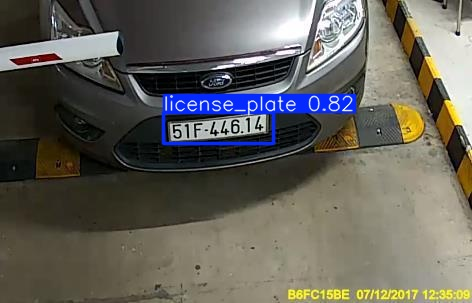

In [10]:
from IPython.display import Image, display
import os
import random
import time

random.seed(time.time())

images_dir = os.path.join(data_yaml["test"], "images")

random_img_name = random.choice(os.listdir(images_dir))
sample_img = os.path.join(images_dir, random_img_name)

results = model.predict(
    source=sample_img, 
    save=True, 
    project='test_predictions', 
    name='output',
    exist_ok=True
)

display(Image(filename=os.path.join(results[0].save_dir, random_img_name)))

Custom upload

In [11]:
import ipywidgets as widgets
from IPython.display import display

uploader = widgets.FileUpload(accept='image/*', multiple=False)
display(uploader)

FileUpload(value=(), accept='image/*', description='Upload')

Uploaded image inference


image 1/1 /kaggle/working/widget_upload.jpg: 384x640 1 license_plate, 40.2ms
Speed: 2.2ms preprocess, 40.2ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)
Results saved to /kaggle/working/runs/detect/test_predictions/output


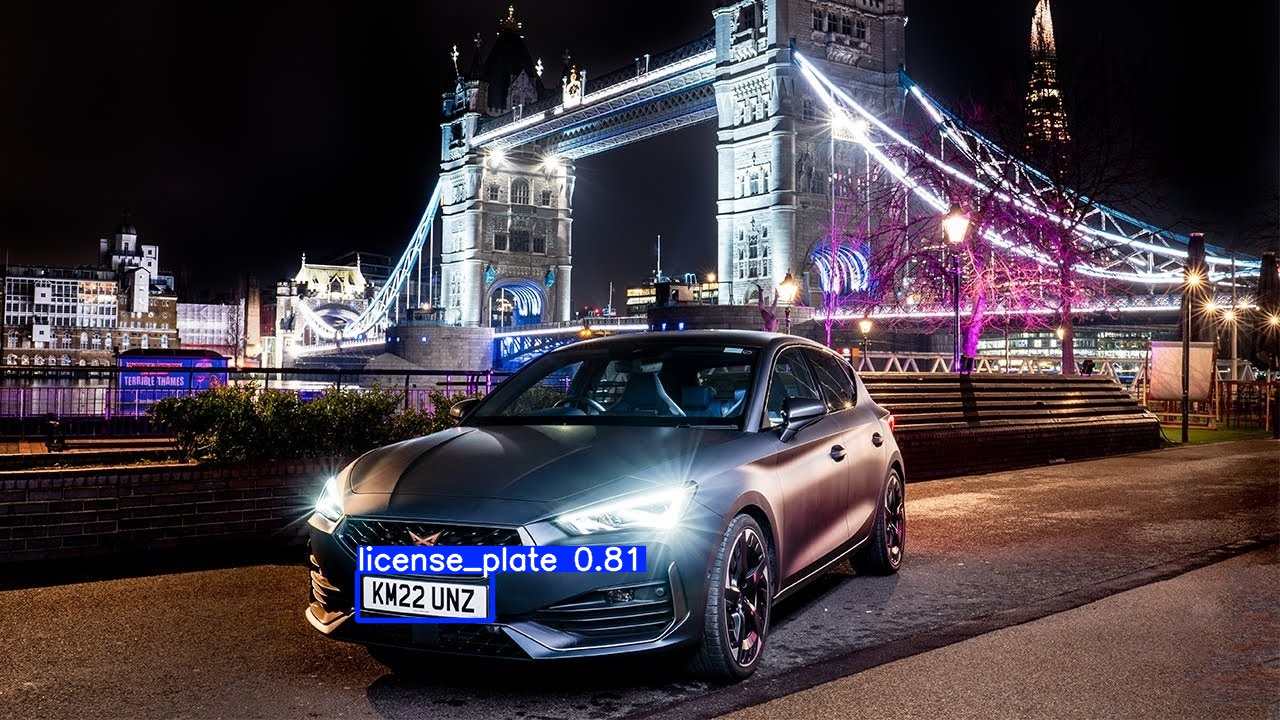

In [18]:
import ipywidgets as widgets
from IPython.display import display, Image
import os

uploaded_file = uploader.value[0]

with open("widget_upload.jpg", "wb") as f:
    f.write(uploaded_file['content'])

results = model.predict(
    source='widget_upload.jpg', 
    save=True,
    project='test_predictions', 
    name='output',
    exist_ok=True,
)

display(Image(filename=os.path.join(results[0].save_dir, 'widget_upload.jpg')))